In [1]:
# load the datapath that has been cleaned and preprocessed 

import pandas as pd

# Dataset paths
DATA_PATHS = {
    "train": "/home/gibannn/kuliah/sem3/paper/SMILES2VEC/code/SMILES/train_set_balanced.xlsx",
    "test":  "/home/gibannn/kuliah/sem3/paper/SMILES2VEC/code/SMILES/test_set_balanced.xlsx",
    "val":   "/home/gibannn/kuliah/sem3/paper/SMILES2VEC/code/SMILES/val_set_balanced.xlsx"
}

print("Datapaths loaded\n")


def load_dataset(path, name):
    """Load dataset and split into features (X) and labels (y)."""
    
    df = pd.read_excel(path)
    
    X = df.drop(columns="labels")
    y = df["labels"]

    print(f"{name.upper()} DATA")
    print(f"X_{name} shape: {X.shape} | y_{name} shape: {y.shape}")
    
    label_dist = y.value_counts().rename(index={0: "Label 0", 1: "Label 1"})
    print("Label distribution:\n", label_dist, "\n")

    return X, y


# Load datasets
X_train, y_train = load_dataset(DATA_PATHS["train"], "train")
X_test, y_test   = load_dataset(DATA_PATHS["test"], "test")
X_val, y_val     = load_dataset(DATA_PATHS["val"], "val")


Datapaths loaded

TRAIN DATA
X_train shape: (8260, 271) | y_train shape: (8260,)
Label distribution:
 labels
Label 0    4167
Label 1    4093
Name: count, dtype: int64 

TEST DATA
X_test shape: (1833, 271) | y_test shape: (1833,)
Label distribution:
 labels
Label 1    940
Label 0    893
Name: count, dtype: int64 

VAL DATA
X_val shape: (1806, 271) | y_val shape: (1806,)
Label distribution:
 labels
Label 1    913
Label 0    893
Name: count, dtype: int64 



In [2]:
vocab_size = int(
    max(
        X_train.to_numpy().max(),
        X_test.to_numpy().max(),
        X_val.to_numpy().max()
    )
)

# Maximum sequence length
MAX_LEN = X_train.shape[1]

print("Dataset Statistics")
print(f"Vocabulary size: {vocab_size}")
print(f"Max sequence length: {MAX_LEN}")

print("\nClass distribution in training set (after ADASYN balancing):")
print(
    y_train.value_counts()
    .rename(index={
        0: "Label 0 (Negative)",
        1: "Label 1 (Positive)"
    })
)

Dataset Statistics
Vocabulary size: 132
Max sequence length: 271

Class distribution in training set (after ADASYN balancing):
labels
Label 0 (Negative)    4167
Label 1 (Positive)    4093
Name: count, dtype: int64


In [3]:
# ================================
# Environment Configuration
# ================================
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"       # Suppress TensorFlow logs
os.environ["CUDA_VISIBLE_DEVICES"] = "0"     # Use GPU 0 and 1
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"      # Disable OneDNN optimizations


# ================================
# Imports
# ================================
import warnings
import random
import time

import numpy as np
import tensorflow as tf
import sklearn.metrics as metrics

warnings.filterwarnings("ignore", category=FutureWarning)


# ================================
# Reproducibility
# ================================
RANDOM_STATE = 116

def set_seeds(seed: int = 116):
    """Set seeds for reproducibility."""
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)


set_seeds(RANDOM_STATE)


# ================================
# GPU Configuration
# ================================
def setup_gpu():
    """Configure TensorFlow GPU memory growth."""
    
    gpus = tf.config.list_physical_devices("GPU")

    if not gpus:
        print("No GPU detected. Using CPU.")
        return

    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)

        logical_gpus = tf.config.list_logical_devices("GPU")

        print(f"GPUs available: {len(gpus)} physical | {len(logical_gpus)} logical")

    except RuntimeError as e:
        print("GPU setup failed:", e)


setup_gpu()


# ================================
# Training Configuration
# ================================
def set_training_config(batch_size=256, iterations=128, epochs=100):
    """Define training hyperparameters."""
    
    config = {
        "BATCH_SIZE": batch_size,
        "ITERATIONS": iterations,
        "EPOCHS": epochs
    }

    return config


TRAIN_CONFIG = set_training_config()

BATCH_SIZE = TRAIN_CONFIG["BATCH_SIZE"]
ITERATIONS = TRAIN_CONFIG["ITERATIONS"]
EPOCHS = TRAIN_CONFIG["EPOCHS"]

print(f"Training config -> Batch: {BATCH_SIZE} | Iterations: {ITERATIONS} | Epochs: {EPOCHS}")

2026-04-08 21:36:08.817595: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-08 21:36:08.818005: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-08 21:36:08.967393: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


GPUs available: 1 physical | 1 logical
Training config -> Batch: 256 | Iterations: 128 | Epochs: 100


In [4]:
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,GRU, Bidirectional,
    Dense, Dropout
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import plot_model



# Paths (simple and portable)

MODEL_DIR = "./model"
IMAGE_DIR = "./image"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(IMAGE_DIR, exist_ok=True)

MODEL_FILE = os.path.join(MODEL_DIR, "best_bigru_conv_model.h5")
MODEL_IMAGE = os.path.join(IMAGE_DIR, "bigru_conv_architecture.png")



# Model Architecture

def build_bigru_conv_model(sequence_length, vocabulary_size):

    set_seeds(RANDOM_STATE)

    model = Sequential([

        # Embedding
        Embedding(
            input_dim=vocabulary_size + 1,
            output_dim=128,
            mask_zero=False
        ),        
        #add second layer of Bidirectional GRU
        Bidirectional(
            GRU(
                64,
                return_sequences=True,
                dropout=0.3
            )
        ),

        # Bidirectional GRU
        Bidirectional(
            GRU(
                32,
                return_sequences=False,
                dropout=0.3
            )
        ),

        # Dense head
        Dense(64, activation="relu"),
        Dropout(0.4),


        # Output layer
        Dense(1, activation="sigmoid")
    ])

    return model



# Build Model

model = build_bigru_conv_model(MAX_LEN, vocab_size)

loss = tf.keras.losses.BinaryFocalCrossentropy(gamma=2)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss=loss,
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
)

model.build(input_shape=(None, MAX_LEN))

print("Model built successfully")
model.summary()



# Callbacks

early_stopping = EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    filepath=MODEL_FILE,
    monitor="val_auc",
    mode="max",
    save_best_only=True,
    verbose=1
)


# Save Model Architecture Diagram
plot_model(
    model,
    to_file=MODEL_IMAGE,
    show_shapes=True,
    show_layer_names=True
)

print(f"Model diagram saved to: {MODEL_IMAGE}")

Model built successfully
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 271, 128)          17024     
                                                                 
 bidirectional (Bidirection  (None, 271, 128)          74496     
 al)                                                             
                                                                 
 bidirectional_1 (Bidirecti  (None, 64)                31104     
 onal)                                                           
                                                                 
 dense (Dense)               (None, 64)                4160      
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (N

In [5]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

def compute_classification_metrics(y_true, y_pred):
    """
    Returns TP, TN, FP, FN, Precision, Recall, F1, Accuracy
    """
    cm = confusion_matrix(y_true, y_pred)
    
    tn, fp, fn, tp = cm.ravel()

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall    = recall_score(y_true, y_pred, zero_division=0)
    f1        = f1_score(y_true, y_pred, zero_division=0)
    accuracy  = accuracy_score(y_true, y_pred)

    return {
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Accuracy": accuracy
    }

print("the function to compute classification metrics have been defined")

the function to compute classification metrics have been defined


In [6]:
import os
import time
import pandas as pd
import numpy as np
import tensorflow as tf
from datetime import timedelta
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


def to_numpy(x):
    """Convert pandas objects to numpy arrays."""
    return x.values if hasattr(x, "values") else x


def train_and_evaluate_model(
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    epochs=100,
    batch_size=128,
    learning_rate=3e-4,
    model_name="BiGRU+CNN",
    model_save_path="./model/best_model.keras",
    patience=5,
    verbose=1
):
    """
    Train and evaluate sequence classification model.
    """

    print(f"TRAINING {model_name}")
    print("=" * 50)

    start_time = time.time()

    # Convert datasets
    X_train, y_train = to_numpy(X_train), to_numpy(y_train)
    X_val, y_val = to_numpy(X_val), to_numpy(y_val)
    X_test, y_test = to_numpy(X_test), to_numpy(y_test)

    
    # Build model
    
    print("\nBuilding model...")
    model = build_bigru_conv_model(MAX_LEN, vocab_size)

    
    # Compile
    
    print("Compiling model...")

    loss_fn = tf.keras.losses.BinaryFocalCrossentropy(gamma=2)

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss=loss_fn,
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc")
        ]
    )

    model.build(input_shape=(None, MAX_LEN))

    if verbose:
        model.summary()

    
    # Callbacks
    
    os.makedirs(os.path.dirname(model_save_path), exist_ok=True)

    callbacks = [

        EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=patience,
            restore_best_weights=True,
            verbose=1
        ),

        ModelCheckpoint(
            filepath=model_save_path,
            monitor="val_auc",
            mode="max",
            save_best_only=True,
            verbose=1
        )
    ]

    
    # Training
    
    print("\nTraining model...")
    print(f"Epochs: {epochs}")
    print(f"Batch size: {batch_size}")
    print(f"Training samples: {len(X_train)}")

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=verbose
    )

    training_time = time.time() - start_time

    
    # Evaluation
    
    print("\nEvaluating model...")

    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred = (y_pred_prob > 0.5).astype(int)

    metrics_dict = compute_classification_metrics(y_test, y_pred)

    results_df = pd.DataFrame([{
        "Model": model_name,
        "Accuracy": metrics_dict["Accuracy"],
        "Precision": metrics_dict["Precision"],
        "Recall": metrics_dict["Recall"],
        "F1": metrics_dict["F1-Score"],
        "TP": metrics_dict["TP"],
        "TN": metrics_dict["TN"],
        "FP": metrics_dict["FP"],
        "FN": metrics_dict["FN"],
        "Training_Time": str(timedelta(seconds=int(training_time))),
        "Epochs": len(history.history["loss"])
    }])

    print("\nTRAINING COMPLETE")
    print("=" * 50)
    print(results_df.to_string(index=False))

    return model, history, results_df

In [7]:
model, history, results = train_and_evaluate_model(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    model_name="BiGRU",
    model_save_path="./model/best_bigru_model.keras"
)

TRAINING BiGRU

Building model...
Compiling model...
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 271, 128)          17024     
                                                                 
 bidirectional_2 (Bidirecti  (None, 271, 128)          74496     
 onal)                                                           
                                                                 
 bidirectional_3 (Bidirecti  (None, 64)                31104     
 onal)                                                           
                                                                 
 dense_2 (Dense)             (None, 64)                4160      
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 

I0000 00:00:1775659049.442307    3837 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


33/33 [==============================] - ETA: 0s - loss: 0.1604 - accuracy: 0.7100 - auc: 0.7807
Epoch 1: val_auc improved from -inf to 0.88935, saving model to ./model/best_bigru_model.keras
33/33 [==============================] - 23s 379ms/step - loss: 0.1604 - accuracy: 0.7100 - auc: 0.7807 - val_loss: 0.1348 - val_accuracy: 0.8134 - val_auc: 0.8894
Epoch 2/100
33/33 [==============================] - ETA: 0s - loss: 0.1111 - accuracy: 0.8229 - auc: 0.8878
Epoch 2: val_auc improved from 0.88935 to 0.93601, saving model to ./model/best_bigru_model.keras
33/33 [==============================] - 8s 235ms/step - loss: 0.1111 - accuracy: 0.8229 - auc: 0.8878 - val_loss: 0.0776 - val_accuracy: 0.8721 - val_auc: 0.9360
Epoch 3/100
33/33 [==============================] - ETA: 0s - loss: 0.0792 - accuracy: 0.8783 - auc: 0.9324
Epoch 3: val_auc improved from 0.93601 to 0.95450, saving model to ./model/best_bigru_model.keras
33/33 [==============================] - 7s 213ms/step - loss: 0.07

58/58 [==============================] - 4s 63ms/step

CLASSIFICATION METRICS ON TEST SET
TP          : 813
TN          : 881
FP          : 12
FN          : 127
Precision   : 0.9855
Recall      : 0.8649
F1-Score    : 0.9212
Accuracy    : 0.9242

✓ Metrics saved to: ./csv/BiGRU+CONV_metrics.csv

TRAINING HISTORY VISUALIZATION
✓ Training history plot saved to: ./image/BiGRU+CONV_history.png


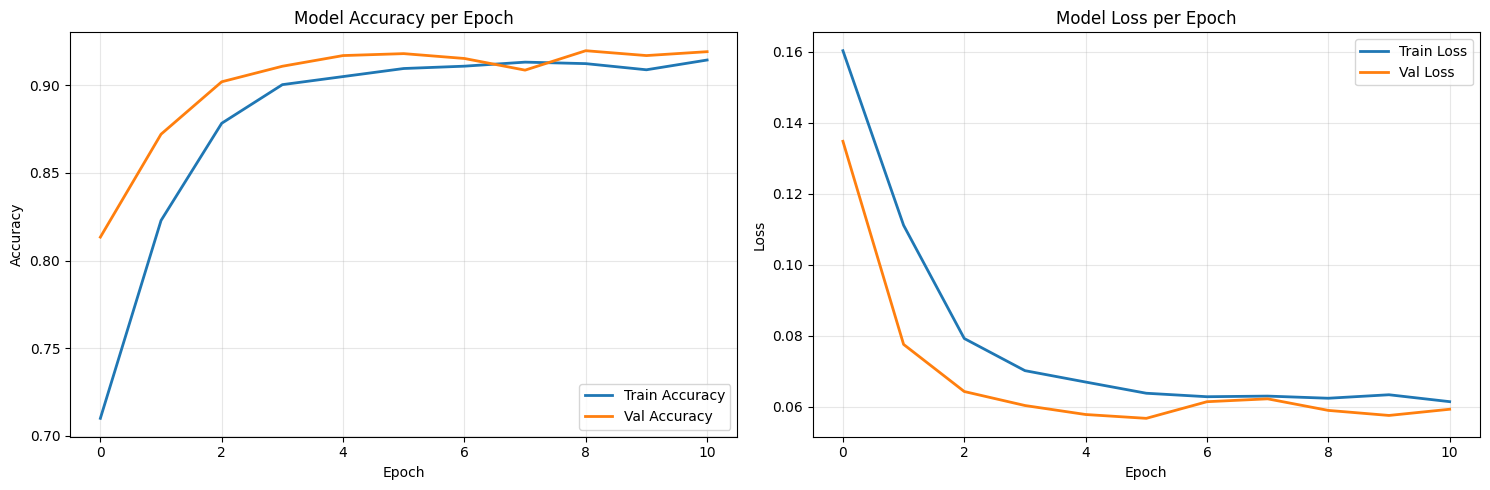

✓ Training history saved to: ./csv/BiGRU+CONV_training_history.csv


In [8]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import os

# ==============================
# Directory setup
# ==============================

MODEL_NAME = "BiGRU+CONV"

CSV_PATH = "./csv"
IMAGE_PATH = "./image"

os.makedirs(CSV_PATH, exist_ok=True)
os.makedirs(IMAGE_PATH, exist_ok=True)

METRIC_FILE = os.path.join(CSV_PATH, f"{MODEL_NAME}_metrics.csv")
HISTORY_FILE = os.path.join(CSV_PATH, f"{MODEL_NAME}_training_history.csv")
PLOT_FILE = os.path.join(IMAGE_PATH, f"{MODEL_NAME}_history.png")


# ==============================
# Metrics Class
# ==============================

class ComputeMetrics:
    """Class to compute and manage classification metrics."""

    def __init__(self, y_true, y_pred):
        self.y_true = y_true.flatten() if y_true.ndim > 1 else y_true
        self.y_pred = y_pred.flatten() if y_pred.ndim > 1 else y_pred

    def get_confusion_matrix(self):
        return confusion_matrix(self.y_true, self.y_pred)

    def get_precision(self):
        return precision_score(self.y_true, self.y_pred, zero_division=0)

    def get_recall(self):
        return recall_score(self.y_true, self.y_pred, zero_division=0)

    def get_f1_score(self):
        return f1_score(self.y_true, self.y_pred, zero_division=0)

    def get_accuracy(self):
        return accuracy_score(self.y_true, self.y_pred)

    def get_all_metrics(self):
        cm = self.get_confusion_matrix()
        tn, fp, fn, tp = cm.ravel()

        return {
            "TP": int(tp),
            "TN": int(tn),
            "FP": int(fp),
            "FN": int(fn),
            "Precision": float(self.get_precision()),
            "Recall": float(self.get_recall()),
            "F1-Score": float(self.get_f1_score()),
            "Accuracy": float(self.get_accuracy())
        }


# ==============================
# Predict
# ==============================

y_pred = (model.predict(X_test) > 0.5).astype(int)

metrics_calculator = ComputeMetrics(y_test, y_pred)
metrics = metrics_calculator.get_all_metrics()

print("\n" + "="*50)
print("CLASSIFICATION METRICS ON TEST SET")
print("="*50)

for key, value in metrics.items():
    if isinstance(value, float):
        print(f"{key:12s}: {value:.4f}")
    else:
        print(f"{key:12s}: {value}")


# ==============================
# Save Metrics
# ==============================

metrics_df = pd.DataFrame([metrics])
metrics_df.insert(0, "Model", MODEL_NAME)
metrics_df.to_csv(METRIC_FILE, index=False)

print(f"\n✓ Metrics saved to: {METRIC_FILE}")


# ==============================
# Plot Training History
# ==============================

print("\n" + "="*50)
print("TRAINING HISTORY VISUALIZATION")
print("="*50)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy
axes[0].plot(history.history["accuracy"], label="Train Accuracy", linewidth=2)
axes[0].plot(history.history["val_accuracy"], label="Val Accuracy", linewidth=2)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Model Accuracy per Epoch")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history["loss"], label="Train Loss", linewidth=2)
axes[1].plot(history.history["val_loss"], label="Val Loss", linewidth=2)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Model Loss per Epoch")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PLOT_FILE, dpi=300, bbox_inches="tight")

print(f"✓ Training history plot saved to: {PLOT_FILE}")

plt.show()


# ==============================
# Save Training History CSV
# ==============================

history_df = pd.DataFrame({
    "epoch": range(1, len(history.history["accuracy"]) + 1),
    "train_accuracy": history.history["accuracy"],
    "val_accuracy": history.history["val_accuracy"],
    "train_loss": history.history["loss"],
    "val_loss": history.history["val_loss"]
})

history_df.to_csv(HISTORY_FILE, index=False)

print(f"✓ Training history saved to: {HISTORY_FILE}")
print("="*50)


CONFUSION MATRIX VISUALIZATION
✓ Confusion matrix saved to: ./image/BiGRU+CONV_confusion_matrix.png


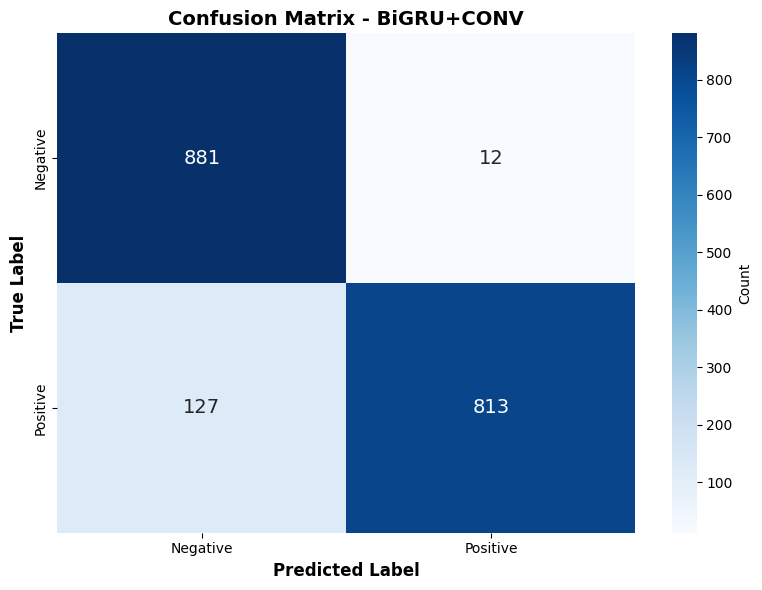


METRICS SUMMARY TABLE
     Model  TP  TN  FP  FN  Precision   Recall  F1-Score  Accuracy
BiGRU+CONV 813 881  12 127   0.985455 0.864894  0.921246  0.924168


In [9]:
import seaborn as sns
import os
from matplotlib import pyplot as plt

MODEL_NAME = "BiGRU+CONV"

IMAGE_PATH = "./image"
os.makedirs(IMAGE_PATH, exist_ok=True)

CM_FILE = os.path.join(IMAGE_PATH, f"{MODEL_NAME}_confusion_matrix.png")


# ==============================
# Confusion Matrix Visualization
# ==============================

print("\n" + "="*50)
print("CONFUSION MATRIX VISUALIZATION")
print("="*50)

cm = metrics_calculator.get_confusion_matrix()

fig, ax = plt.subplots(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative","Positive"],
    yticklabels=["Negative","Positive"],
    cbar_kws={"label":"Count"},
    annot_kws={"size":14},
    ax=ax
)

ax.set_xlabel("Predicted Label", fontsize=12, fontweight="bold")
ax.set_ylabel("True Label", fontsize=12, fontweight="bold")
ax.set_title(f"Confusion Matrix - {MODEL_NAME}", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig(CM_FILE, dpi=300, bbox_inches="tight")

print(f"✓ Confusion matrix saved to: {CM_FILE}")

plt.show()


# ==============================
# Metrics Summary Table
# ==============================

print("\n" + "="*50)
print("METRICS SUMMARY TABLE")
print("="*50)

print(metrics_df.to_string(index=False))

print("="*50)